In [ ]:
import pandas as pd

raw = pd.read_csv("data/almaty_apartments_raw.csv")
YOUR_ID = 1234  

ids = raw["listing_id"].drop_duplicates().sample(frac=0.9, random_state=YOUR_ID)
df = raw[raw["listing_id"].isin(ids)].reset_index(drop=True)

print(df.shape)
print(df.dtypes)
print(df.isna().sum())
print(df.describe(include="all").T)


(1153, 11)
listing_id              str
listed_date             str
district                str
rooms                   str
area_m2                 str
floor                 int64
total_floors          int64
year_built          float64
building_type           str
ceiling_height_m    float64
price_kzt               str
dtype: object
listing_id            0
listed_date           0
district              0
rooms                 0
area_m2               0
floor                 0
total_floors          0
year_built           53
building_type         0
ceiling_height_m    130
price_kzt             0
dtype: int64
                   count unique         top freq         mean         std  \
listing_id          1153   1080   ALM-10003    3          NaN         NaN   
listed_date         1153    246  2026-04-18   11          NaN         NaN   
district            1153     47       Medeu  146          NaN         NaN   
rooms               1153      6           2  434          NaN         NaN   
area_

In [4]:

print("Rows before drop_duplicates:", len(df))
df = df.drop_duplicates().reset_index(drop=True)


df["listed_date"] = pd.to_datetime(df["listed_date"])

df = df.sort_values("listed_date").drop_duplicates("listing_id", keep="last").reset_index(drop=True)
print("Rows after cleaning reposts:", len(df))

Rows before drop_duplicates: 1080
Rows after cleaning reposts: 1080


In [5]:
print(df["district"].value_counts(dropna=False))


district_mapping = {
    "alatau": "Alatau", "алатау": "Alatau",
    "almaly": "Almaly", "алмалы": "Almaly",
    "auezov": "Auezov", "ауэзов": "Auezov",
    "bostandyk": "Bostandyk", "бостандык": "Bostandyk",
    "medeu": "Medeu", "медеу": "Medeu", "медеуский": "Medeu",
    "nauryzbay": "Nauryzbay", "наурызбай": "Nauryzbay",
    "turksib": "Turksib", "турксиб": "Turksib",
    "zhetysu": "Zhetysu", "жетысу": "Zhetysu"
}

df["district"] = df["district"].str.strip().str.lower().map(district_mapping)

print("Missing district values (must be 0):", df["district"].isna().sum())
print("Unique districts count (must be 8):", df["district"].nunique())

district
Medeu            136
Turksib          123
Bostandyk        120
Auezov           114
Zhetysu          114
Almaly           107
Alatau           106
Nauryzbay        102
medeu             10
Наурызбайский      8
turksib            8
 Auezov            7
AUEZOV             7
auezov             6
bostandyk          6
Auezovskiy         6
Alatauskiy         6
Almalinskiy        5
ALMALY             5
nauryzbay          5
 Zhetysu           5
 Alatau            4
Nauryzbayskiy      4
TURKSIB            4
BOSTANDYK          4
Медеуский          4
ZHETYSU            4
 Turksib           4
 Medeu             4
MEDEU              4
 Bostandyk         4
Bostandykskiy      4
Zhetysuskiy        3
 Almaly            3
almaly             3
Турксибский        3
Medeuskiy          2
Ауэзовский         2
NAURYZBAY          2
Turksibskiy        2
 Nauryzbay         2
zhetysu            2
ALATAU             2
alatau             1
Бостандыкский      1
Алатауский         1
Алмалинский        1
Name

In [6]:
import numpy as np

df["price_kzt"] = df["price_kzt"].astype(str).str.replace(r"\D", "", regex=True).astype(float)


df["area_m2"] = (
    df["area_m2"].astype(str)
    .str.replace("m²", "", regex=False)
    .str.strip()
    .str.replace(",", ".", regex=False)
    .astype(float)
)

df["rooms"] = df["rooms"].astype(str).str.lower().str.replace("studio", "1", regex=False)
df["rooms"] = df["rooms"].str.replace(r"\D", "", regex=True).astype(float)

print(df[["price_kzt", "area_m2", "rooms"]].dtypes)

price_kzt    float64
area_m2      float64
rooms        float64
dtype: object


In [7]:
import numpy as np


for col in ["year_built", "ceiling_height_m", "area_m2", "price_kzt", "rooms"]:
    if col in df.columns:
        df[col] = df[col].replace(0, np.nan)
        df.loc[df[col] < 0, col] = np.nan


df.loc[df["floor"] > df["total_floors"], "floor"] = np.nan

df["area_before_fix"] = df["area_m2"]
df["price_per_m2"] = df["price_kzt"] / df["area_m2"]


import os
os.makedirs("data", exist_ok=True)
df.to_csv("data/almaty_apartments_clean.csv", index=False)
print("data/almaty_apartments_clean.csv ")

data/almaty_apartments_clean.csv 


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

NUMERIC = ["rooms", "area_m2", "floor", "total_floors", "year_built", "ceiling_height_m"]


train, test = train_test_split(df, test_size=0.2, random_state=YOUR_ID)
train, test = train.copy(), test.copy()


rate = train.assign(missing=train["ceiling_height_m"].isna()).groupby("building_type")["missing"].mean()
print("Building type бойынша missing rate:\n", rate)


known = train[train["ceiling_height_m"].notna()]
hidden = known.sample(frac=0.15, random_state=YOUR_ID).index
rest = train.drop(index=hidden)
answers = train.loc[hidden, "ceiling_height_m"]


global_med = rest["ceiling_height_m"].median()
mae_global = mean_absolute_error(answers, [global_med] * len(hidden))


group_med = rest.groupby("building_type")["ceiling_height_m"].median()
preds_group = hidden.map(lambda idx: rest.loc[idx, "building_type"]).map(group_med).fillna(global_med)
mae_group = mean_absolute_error(answers, preds_group)

print(f"Global median MAE: {mae_global:.4f}")
print(f"Grouped median MAE: {mae_group:.4f}")


ceil_meds = train.groupby("building_type")["ceiling_height_m"].median()
for frame in (train, test):
    frame["ceiling_height_m"] = frame["ceiling_height_m"].fillna(frame["building_type"].map(ceil_meds)).fillna(train["ceiling_height_m"].median())
    frame["year_built"] = frame["year_built"].fillna(train["year_built"].median())
    frame["floor"] = frame["floor"].fillna(train["floor"].median())

print("\nTrain NUMERIC NaNs қалды:", train[NUMERIC].isna().sum().sum())
print("Test NUMERIC NaNs қалды:", test[NUMERIC].isna().sum().sum())

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

for scaler in (StandardScaler(), MinMaxScaler(), RobustScaler()):
    scaled = scaler.fit_transform(train[["area_before_fix"]]).ravel()
    q1, q3 = np.percentile(scaled, [25, 75])
    print(f"{type(scaler).__name__:15s} IQR={q3 - q1:.3f}  min={scaled.min():.2f}  max={scaled.max():.2f}")

CATEGORICAL = ["district", "building_type"]
pre = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
])

X_train = pre.fit_transform(train[NUMERIC + CATEGORICAL])
X_test = pre.transform(test[NUMERIC + CATEGORICAL])

model = LinearRegression().fit(X_train, train["price_kzt"])
print("\nShapes -> X_train:", X_train.shape, "X_test:", X_test.shape)
print("NaN count -> X_train:", np.isnan(X_train).sum(), "X_test:", np.isnan(X_test).sum())
print(f"Test R²: {model.score(X_test, test['price_kzt']):.4f}")

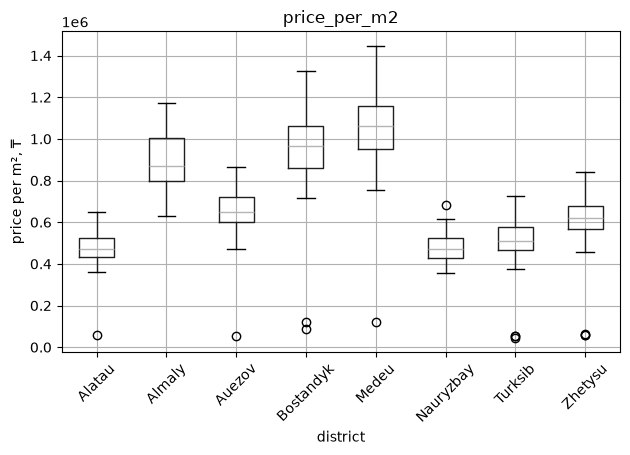

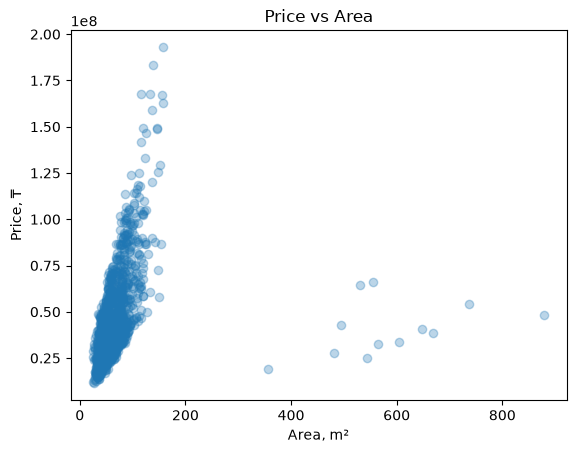

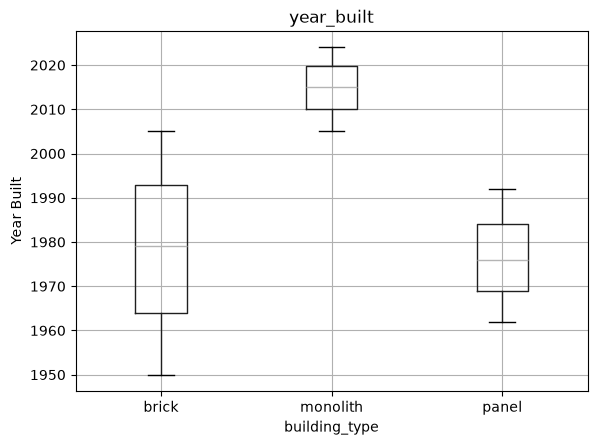

In [8]:
import matplotlib.pyplot as plt

df.boxplot(column="price_per_m2", by="district", rot=45)
plt.ylabel("price per m², ₸")
plt.suptitle("")
plt.tight_layout()
plt.show()

plt.scatter(df["area_m2"], df["price_kzt"], alpha=0.3)
plt.xlabel("Area, m²")
plt.ylabel("Price, ₸")
plt.title("Price vs Area")
plt.show()

df.boxplot(column="year_built", by="building_type")
plt.ylabel("Year Built")
plt.suptitle("")
plt.show()